# Set up

## Change working directory

In [1]:
%cd ../

C:\Users\Skylar\Downloads\tools


C:\Users\Skylar\Downloads\tools\env\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Install packages

In [2]:
# Placeholder

## Import development libraries

In [3]:
import hypothesis
import ipytest
import seaborn as sns
from hypothesis import strategies as st
from pandera import pandas as pa
from tools import typing as tstg

ipytest.autoconfig(rewrite_asserts=False)
sns.set()

## Import other libraries

In [4]:
import itertools
import typing

import numpy as np
import pandas as pd
import toolz as tz
import tqdm
from matplotlib import pyplot as plt

## Declare constants

In [5]:
module: str = "data_analysis"

# Define describe_dataset

## Define

In [6]:
def describe_dataset(data: pd.DataFrame) -> pd.DataFrame:
    def get_most_frequent_values(data: pd.Series) -> dict:
        return data.value_counts(normalize=True).nlargest().round(decimals=3).to_dict()

    def describe(data: pd.DataFrame) -> pd.DataFrame:
        assign_args: dict[str, typing.Callable] = {
            "iqr": lambda x: x["75%"].sub(other=x["25%"]),
            "has_low_outlier": lambda x: x["iqr"].mul(other=1.5).rsub(other=x["25%"]).gt(other=x["min"]),
            "has_high_outlier": lambda x: x["iqr"].mul(other=1.5).add(other=x["75%"]).lt(other=x["max"]),
            "has_outlier": lambda x: x.filter(like="outlier").any(axis=1),
        }
        return data.describe().T.assign(**assign_args).drop(columns="count")

    objs: list[pd.DataFrame | pd.Series] = [
        data.dtypes.astype(dtype=str).rename(index="dtypes"),
        data.nunique().rename(index="nunique"),
        data.apply(func=get_most_frequent_values).rename(index="frequent_values"),
        data.isna().mean().rename(index="pct_missing"),
        data.isin(values=[-np.inf, np.inf]).mean().rename(index="pct_inf"),
        data.select_dtypes(include="number").lt(other=0).mean().rename(index="pct_negative"),
        data.eq(other=0).mean().rename(index="pct_zero"),
        data.pipe(func=describe),
    ]
    return pd.concat(objs=objs, axis=1).sort_values(by=["dtypes", "nunique"]).round(decimals=3)

## Demonstrate

In [7]:
titanic_data: pd.DataFrame = sns.load_dataset(name="titanic")
describe_dataset(data=titanic_data)

,dtypes,nunique,frequent_values,pct_missing,pct_inf,pct_negative,pct_zero,mean,std,min,25%,50%,75%,max,iqr,has_low_outlier,has_high_outlier,has_outlier
adult_male,bool,2,"{True: 0.603, False: 0.397}",0.000,0.0,NaN,0.397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alone,bool,2,"{True: 0.603, False: 0.397}",0.000,0.0,NaN,0.397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,category,3,"{'Third': 0.551, 'First': 0.242, 'Second': 0.207}",0.000,0.0,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deck,category,7,"{'C': 0.291, 'B': 0.232, 'D': 0.163, 'E': 0.15...",0.772,0.0,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,float64,88,"{24.0: 0.042, 22.0: 0.038, 18.0: 0.036, 28.0: ...",0.199,0.0,0.0,0.000,29.699,14.526,0.42,20.125,28.000,38.0,80.000,17.875,False,True,True
fare,float64,248,"{8.05: 0.048, 13.0: 0.047, 7.8958: 0.043, 7.75...",0.000,0.0,0.0,0.017,32.204,49.693,0.00,7.910,14.454,31.0,512.329,23.090,False,True,True
survived,int64,2,"{0: 0.616, 1: 0.384}",0.000,0.0,0.0,0.616,0.384,0.487,0.00,0.000,0.000,1.0,1.000,1.000,False,False,False
pclass,int64,3,"{3: 0.551, 1: 0.242, 2: 0.207}",0.000,0.0,0.0,0.000,2.309,0.836,1.00,2.000,3.000,3.0,3.000,1.000,False,False,False
sibsp,int64,7,"{0: 0.682, 1: 0.235, 2: 0.031, 4: 0.02, 3: 0.018}",0.000,0.0,0.0,0.682,0.523,1.103,0.00,0.000,0.000,1.0,8.000,1.000,False,True,True
parch,int64,7,"{0: 0.761, 1: 0.132, 2: 0.09, 5: 0.006, 3: 0.006}",0.000,0.0,0.0,0.761,0.382,0.806,0.00,0.000,0.000,0.0,6.000,0.000,False,True,True


## Test

In [8]:
%%ipytest

def test_high_outlier() -> None:
    data = pd.DataFrame(data={'a': [1, 2, 3, 1e2]})
    out: pd.DataFrame = describe_dataset(data=data)
    assert out.loc['a', 'has_high_outlier'] == True

def test_low_outlier() -> None:
    data = pd.DataFrame(data={'a': [-1e2, 1, 2, 3]})
    out: pd.DataFrame = describe_dataset(data=data)
    assert out.loc['a', 'has_low_outlier'] == True

..                                                                                           [100%]
======================================== warnings summary =========================================
env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define describe_datasets

## Define

In [9]:
def describe_datasets(
    reference_data: pd.DataFrame,
    current_data: pd.DataFrame,
    filter_to_common_columns: bool = True,
    filter_to_differences: bool = True,
) -> pd.DataFrame:
    common_columns: pd.Index = reference_data.columns.intersection(other=current_data.columns)
    objs: list[pd.Series] = tz.pipe(
        [reference_data, current_data],
        tz.curried.map(lambda x: x.loc[:, common_columns] if filter_to_common_columns else x),
        tz.curried.map(lambda x: describe_dataset(data=x).select_dtypes(include="number").stack()),
        list,
    )
    assign_args: dict[str, typing.Callable] = {"difference": lambda x: x.diff(axis=1).iloc[:, -1]}
    description: pd.DataFrame = pd.concat(objs=objs, axis=1, keys=["reference", "current"]).assign(**assign_args)
    if filter_to_differences:
        eps: float = np.finfo(dtype=float).eps
        return description.loc[lambda x: x["difference"].abs().gt(other=eps), :]
    return description

## Demonstrate

In [10]:
titanic_train_data: pd.DataFrame = titanic_data.sample(frac=8e-1)
titanic_test_data: pd.DataFrame = titanic_data.drop(index=titanic_train_data.index)
datasets_description: pd.DataFrame = describe_datasets(
    reference_data=titanic_train_data, current_data=titanic_test_data
)
datasets_description

reference  current  difference
adult_male  pct_zero         0.410    0.348      -0.062
alone       pct_zero         0.404    0.371      -0.033
deck        nunique          7.000    6.000      -1.000
            pct_missing      0.774    0.764      -0.010
age         nunique         86.000   52.000     -34.000
            pct_missing      0.199    0.197      -0.002
            mean            29.495   30.513       1.018
            std             14.618   14.177      -0.441
            min              0.420    0.830       0.410
            25%             20.000   21.000       1.000
            50%             28.000   29.000       1.000
            75%             38.000   38.500       0.500
            max             80.000   70.500      -9.500
            iqr             18.000   17.500      -0.500
fare        nunique        223.000  103.000    -120.000
            mean            32.074   32.726       0.652
            std             52.017   39.147     -12.870
            25%              7.896    8.050       0.154
            50%             14.454   15.173       0.719
            75%             30.000   41.106      11.106
            max            512.329  227.525    -284.804
            iqr             22.104   33.056      10.952
survived    pct_zero         0.609    0.646       0.037
            mean             0.391    0.354      -0.037
            std              0.488    0.480      -0.008
pclass      mean             2.327    2.236      -0.091
            std              0.832    0.851       0.019
            25%              2.000    1.000      -1.000
            iqr              1.000    2.000       1.000
sibsp       pct_zero         0.672    0.725       0.053
            mean             0.537    0.466      -0.071
            std              1.109    1.080      -0.029
parch       nunique          7.000    6.000      -1.000
            pct_zero         0.760    0.764       0.004
            mean             0.379    0.393       0.014
            std              0.802    0.825       0.023
            max              6.000    5.000      -1.000
embarked    pct_missing      0.001    0.006       0.005
embark_town pct_missing      0.001    0.006       0.005

## Test

In [11]:
%%ipytest

def test_common_columns() -> None:
    ref = pd.DataFrame(data={'a': range(1, 4), 'b': range(4, 7)})
    cur = pd.DataFrame(data={'a': range(1, 4), 'c': range(4, 7)})
    shared_args = dict(reference_data=ref, current_data=cur, filter_to_differences=False)
    out: pd.DataFrame = describe_datasets(filter_to_common_columns=True, **shared_args)
    assert 'a' in out.index.get_level_values(level=0)
    assert 'b' not in out.index.get_level_values(level=0)
    out: pd.DataFrame = describe_datasets(filter_to_common_columns=False, **shared_args)
    assert 'b' in out.index.get_level_values(level=0)

def test_zero_differences() -> None:
    ref = pd.DataFrame(data={'a': range(1, 4)})
    cur = pd.DataFrame(data={'a': range(1, 4)})
    shared_args = dict(reference_data=ref, current_data=cur, filter_to_common_columns=True)
    out: pd.DataFrame = describe_datasets(filter_to_differences=True, **shared_args)
    assert out.empty
    out: pd.DataFrame = describe_datasets(filter_to_differences=False, **shared_args)
    assert not out.empty
    assert out['difference'].eq(other=0).all()

..                                                                                           [100%]
======================================== warnings summary =========================================
env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define get_correlations

## Define

In [12]:
def get_correlations(X: pd.DataFrame, y: pd.Series | None = None, method: str = "spearman") -> pd.Series:
    X_numeric: pd.DataFrame = X.select_dtypes(include="number")
    if y is None:
        column_pairs: list[tuple[str, str]] = sorted(itertools.combinations(iterable=X_numeric.columns, r=2))
        correlations: dict[tuple[str, str], float] = {}
        for column_pair in tqdm.tqdm(iterable=column_pairs):  # type: tuple[str, str]
            correlation: float = X_numeric[list(column_pair)].corr(method=method).iloc[0, 1]
            correlations[column_pair] = 0e0 if pd.isna(obj=correlation) else correlation  # Handle constant columns
        return pd.Series(data=correlations, name=method).sort_values()
    return X_numeric.corrwith(other=y, method=method).fillna(value=0).rename(index=method).sort_values()

## Demonstrate

In [13]:
target: str = "survived"
X_train: pd.DataFrame = titanic_train_data.drop(columns=target)
y_train: pd.Series = titanic_train_data[target]
correlations_between_features: pd.Series = get_correlations(X=X_train)
correlations_with_target: pd.Series = get_correlations(X=X_train, y=y_train)
correlations_between_features, correlations_with_target

100%|█████████████████████████████████| 10/10 [00:00<00:00, 338.38it/s]


(pclass  fare    -0.672045
         age     -0.353298
 age     parch   -0.303349
         sibsp   -0.191699
 pclass  sibsp   -0.033172
         parch    0.002764
 age     fare     0.112375
 parch   fare     0.400019
 sibsp   fare     0.458706
         parch    0.459912
 Name: spearman, dtype: float64,
 pclass   -0.338154
 age      -0.082082
 sibsp     0.092331
 parch     0.145966
 fare      0.337245
 Name: spearman, dtype: float64)

## Test

In [14]:
%%ipytest

def test_perfect_correlation() -> None:
    X = pd.DataFrame(data={'a': range(1, 4), 'b': range(1, 4)})
    out: pd.Series = get_correlations(X=X)
    assert out.loc['a'].loc['b'] == 1e0

def test_constant_column() -> None:
    X = pd.DataFrame(data={'a': range(1, 4), 'b': 1})
    out: pd.Series = get_correlations(X=X)
    assert out.loc['a'].loc['b'] == 0e0

def test_nonnumeric_columns() -> None:
    X = pd.DataFrame(data={'a': range(1, 4), 'b': list('abc')})
    out: pd.Series = get_correlations(X=X)
    assert out.empty

def test_perfect_correlations_with_target() -> None:
    X = pd.DataFrame(data={'a': range(1, 4), 'b': range(3, 0, -1)})
    y = pd.Series(data=range(1, 4))
    out: pd.Series = get_correlations(X=X, y=y)
    assert out['a'] == 1e0
    assert out['b'] == -1e0

....                                                                                         [100%]
======================================== warnings summary =========================================
env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define get_differences

## Define

In [15]:
def get_differences(data: pd.DataFrame, first_column: str, second_column: str) -> pd.DataFrame:
    columns: list[str] = [first_column, second_column]
    assign_args: dict[str, typing.Callable] = {
        "abs_diff": lambda x: x.loc[:, columns].diff(axis=1).iloc[:, -1].abs(),
        "mean": lambda x: x.loc[:, columns].mean(axis=1),
        "pct_diff": lambda x: x["abs_diff"].div(other=x["mean"].where(cond=x["mean"].ne(other=0))),
    }
    return data.assign(**assign_args)

## Demonstrate

In [16]:
datasets_differences: pd.DataFrame = get_differences(
    data=datasets_description, first_column="reference", second_column="current"
)
datasets_differences

reference  current  difference  abs_diff      mean  \
adult_male  pct_zero         0.410    0.348      -0.062     0.062    0.3790   
alone       pct_zero         0.404    0.371      -0.033     0.033    0.3875   
deck        nunique          7.000    6.000      -1.000     1.000    6.5000   
            pct_missing      0.774    0.764      -0.010     0.010    0.7690   
age         nunique         86.000   52.000     -34.000    34.000   69.0000   
            pct_missing      0.199    0.197      -0.002     0.002    0.1980   
            mean            29.495   30.513       1.018     1.018   30.0040   
            std             14.618   14.177      -0.441     0.441   14.3975   
            min              0.420    0.830       0.410     0.410    0.6250   
            25%             20.000   21.000       1.000     1.000   20.5000   
            50%             28.000   29.000       1.000     1.000   28.5000   
            75%             38.000   38.500       0.500     0.500   38.2500   
            max             80.000   70.500      -9.500     9.500   75.2500   
            iqr             18.000   17.500      -0.500     0.500   17.7500   
fare        nunique        223.000  103.000    -120.000   120.000  163.0000   
            mean            32.074   32.726       0.652     0.652   32.4000   
            std             52.017   39.147     -12.870    12.870   45.5820   
            25%              7.896    8.050       0.154     0.154    7.9730   
            50%             14.454   15.173       0.719     0.719   14.8135   
            75%             30.000   41.106      11.106    11.106   35.5530   
            max            512.329  227.525    -284.804   284.804  369.9270   
            iqr             22.104   33.056      10.952    10.952   27.5800   
survived    pct_zero         0.609    0.646       0.037     0.037    0.6275   
            mean             0.391    0.354      -0.037     0.037    0.3725   
            std              0.488    0.480      -0.008     0.008    0.4840   
pclass      mean             2.327    2.236      -0.091     0.091    2.2815   
            std              0.832    0.851       0.019     0.019    0.8415   
            25%              2.000    1.000      -1.000     1.000    1.5000   
            iqr              1.000    2.000       1.000     1.000    1.5000   
sibsp       pct_zero         0.672    0.725       0.053     0.053    0.6985   
            mean             0.537    0.466      -0.071     0.071    0.5015   
            std              1.109    1.080      -0.029     0.029    1.0945   
parch       nunique          7.000    6.000      -1.000     1.000    6.5000   
            pct_zero         0.760    0.764       0.004     0.004    0.7620   
            mean             0.379    0.393       0.014     0.014    0.3860   
            std              0.802    0.825       0.023     0.023    0.8135   
            max              6.000    5.000      -1.000     1.000    5.5000   
embarked    pct_missing      0.001    0.006       0.005     0.005    0.0035   
embark_town pct_missing      0.001    0.006       0.005     0.005    0.0035   

                         pct_diff  
adult_male  pct_zero     0.163588  
alone       pct_zero     0.085161  
deck        nunique      0.153846  
            pct_missing  0.013004  
age         nunique      0.492754  
            pct_missing  0.010101  
            mean         0.033929  
            std          0.030630  
            min          0.656000  
            25%          0.048780  
            50%          0.035088  
            75%          0.013072  
            max          0.126246  
            iqr          0.028169  
fare        nunique      0.736196  
            mean         0.020123  
            std          0.282348  
            25%          0.019315  
            50%          0.048537  
            75%          0.312379  
            max          0.769892  
            iqr          0.397099  
survived    pct_zero     0.058964  


## Test

In [17]:
%%ipytest

# Helper(s)
columns: dict[str, pa.Column] = {
    "a": pa.Column(dtype=float, nullable=True),
    "b": pa.Column(dtype=float, nullable=True)
}
data_strategy: st.SearchStrategy[pd.DataFrame] = pa.DataFrameSchema(columns=columns).strategy(size=5)

# Deterministic test(s)
def test_division_by_zero() -> None:
    data = pd.DataFrame(data={'a': [0] * 3, 'b': [0] * 3})
    out: pd.DataFrame = get_differences(data=data, first_column='a', second_column='b')
    assert out['pct_diff'].isna().all()

def test_na_propagation() -> None:
    data = pd.DataFrame(data={'a': [0, np.nan, 2], 'b': [1, 2, np.nan]})
    out: pd.DataFrame = get_differences(data=data, first_column='a', second_column='b')
    assert out['pct_diff'].iloc[1:].isna().all()

# Property-based test(s)
@hypothesis.given(data=data_strategy)
def test_symmetric_percent_difference(data: pd.DataFrame) -> None:
    first_differences: pd.DataFrame = get_differences(data=data, first_column='a', second_column='b')
    second_differences: pd.DataFrame = get_differences(data=data, first_column='b', second_column='a')
    pd.testing.assert_series_equal(left=first_differences['pct_diff'], right=second_differences['pct_diff'])

...                                                                                          [100%]
======================================== warnings summary =========================================
env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define plot_histogram

## Define

In [18]:
def plot_histogram(data: pd.Series, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs) -> plt.Axes:
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = data.plot(kind="hist", **filtered_kwargs)
    pd.plotting.table(ax=ax, data=data.describe().round(decimals=3), bbox=bbox)
    return ax

## Demonstrate

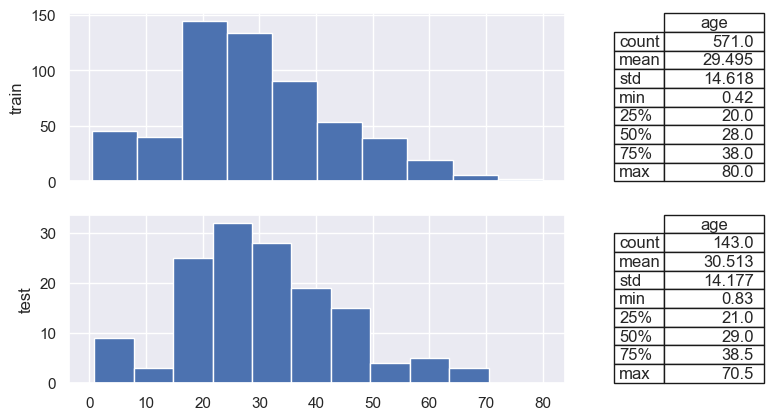

In [19]:
fig, axes = plt.subplots(nrows=2, sharex=True)  # type: tstg.FigAxes
for split, ax in zip(["train", "test"], axes.flat):  # type: tuple[str, plt.Axes]
    plot_histogram(data=eval("titanic_%s_data" % split)["age"], ax=ax)
    ax.set(ylabel=split)

## Test

In [20]:
# Placeholder

# Define plot_largest_barh

## Define

In [21]:
def plot_largest_barh(
    data: pd.Series, n: int = int(1e1), return_signed: bool = True, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs
) -> plt.Axes:
    largest_unsigned_data: pd.Series = data.abs().nlargest(n=n).iloc[::-1]
    largest_signed_data: pd.Series = data.loc[largest_unsigned_data.index].sort_values()
    plot_data: pd.Series = largest_signed_data if return_signed else largest_unsigned_data
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = plot_data.plot(kind="barh", **filtered_kwargs)
    formatted_data: pd.Series = plot_data.reset_index(drop=True).round(decimals=3).iloc[::-1]
    pd.plotting.table(ax=ax, data=formatted_data, bbox=bbox)
    return ax

## Demonstrate

<Axes: >

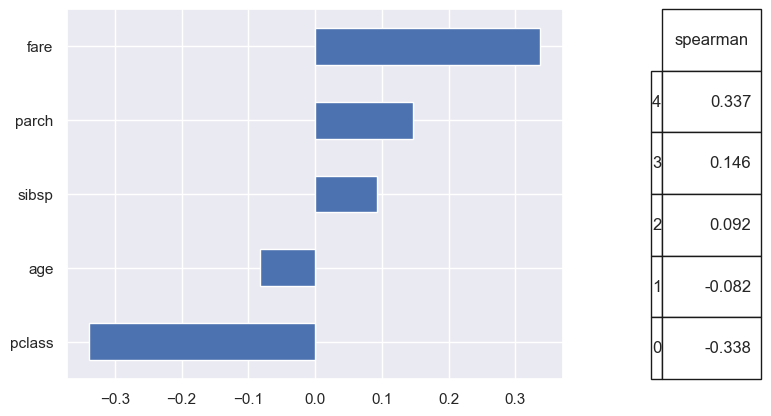

In [22]:
plot_largest_barh(data=correlations_with_target)

## Test

In [23]:
# Placeholder

# Define plot_value_counts

## Define

In [24]:
def plot_value_counts(data: pd.Series, n: int = int(1e1), bbox: list | tuple | None = None, **kwargs) -> plt.Axes:
    plot_data: pd.DataFrame = (
        data.value_counts(dropna=False)
        .to_frame(name="cnt")
        .assign(**{"pct": lambda x: x["cnt"].pipe(func=lambda y: y.div(other=y.sum()))})
        .nlargest(n=n, columns="cnt")
    )
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = plot_data["cnt"].iloc[::-1].plot(kind="barh", **filtered_kwargs)
    if bbox is None:
        bbox = (1.2, 0, 4e-1, 2e-1 * plot_data.shape[0])
    pd.plotting.table(ax=ax, data=plot_data.round(decimals=3), bbox=bbox)
    return ax

## Demonstrate

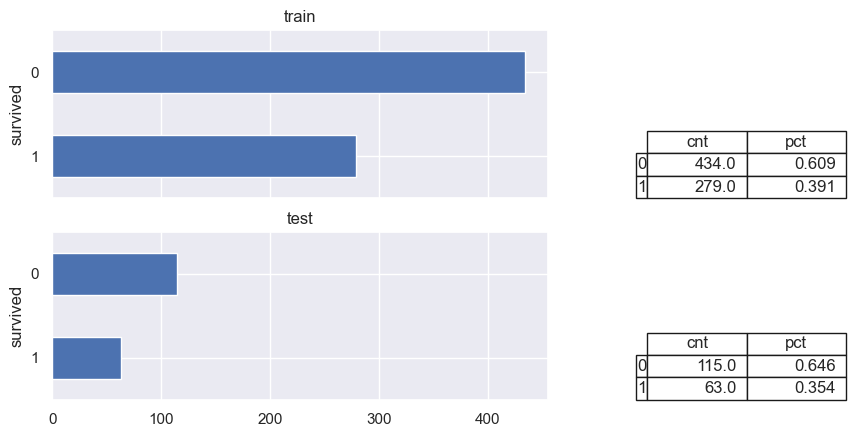

In [25]:
fig, axes = plt.subplots(nrows=2, sharex=True)  # type: tstg.FigAxes
for split, ax in zip(["train", "test"], axes.flat):  # type: tuple[str, plt.Axes]
    plot_value_counts(data=eval("titanic_%s_data" % split)[target], ax=ax)
    ax.set(title=split)

## Test

In [26]:
# Placeholder

# Write module

## Write

In [27]:
module_path: str = "src/tools/%s.py" % module

In [28]:
%%file $module_path

import itertools
import typing

import numpy as np
import pandas as pd
import toolz as tz
import tqdm
from matplotlib import pyplot as plt

def describe_dataset(data: pd.DataFrame) -> pd.DataFrame:
    def get_most_frequent_values(data: pd.Series) -> dict:
        return data.value_counts(normalize=True).nlargest().round(decimals=3).to_dict()

    def describe(data: pd.DataFrame) -> pd.DataFrame:
        assign_args: dict[str, typing.Callable] = {
            "iqr": lambda x: x["75%"].sub(other=x["25%"]),
            "has_low_outlier": lambda x: x["iqr"].mul(other=1.5).rsub(other=x["25%"]).gt(other=x["min"]),
            "has_high_outlier": lambda x: x["iqr"].mul(other=1.5).add(other=x["75%"]).lt(other=x["max"]),
            "has_outlier": lambda x: x.filter(like="outlier").any(axis=1),
        }
        return data.describe().T.assign(**assign_args).drop(columns="count")

    objs: list[pd.DataFrame | pd.Series] = [
        data.dtypes.astype(dtype=str).rename(index="dtypes"),
        data.nunique().rename(index="nunique"),
        data.apply(func=get_most_frequent_values).rename(index="frequent_values"),
        data.isna().mean().rename(index="pct_missing"),
        data.isin(values=[-np.inf, np.inf]).mean().rename(index="pct_inf"),
        data.select_dtypes(include="number").lt(other=0).mean().rename(index="pct_negative"),
        data.eq(other=0).mean().rename(index="pct_zero"),
        data.pipe(func=describe),
    ]
    return pd.concat(objs=objs, axis=1).sort_values(by=["dtypes", "nunique"]).round(decimals=3)

def describe_datasets(
    reference_data: pd.DataFrame,
    current_data: pd.DataFrame,
    filter_to_common_columns: bool = True,
    filter_to_differences: bool = True,
) -> pd.DataFrame:
    common_columns: pd.Index = reference_data.columns.intersection(other=current_data.columns)
    objs: list[pd.Series] = tz.pipe(
        [reference_data, current_data],
        tz.curried.map(lambda x: x.loc[:, common_columns] if filter_to_common_columns else x),
        tz.curried.map(lambda x: describe_dataset(data=x).select_dtypes(include="number").stack()),
        list,
    )
    assign_args: dict[str, typing.Callable] = {"difference": lambda x: x.diff(axis=1).iloc[:, -1]}
    description: pd.DataFrame = pd.concat(objs=objs, axis=1, keys=["reference", "current"]).assign(**assign_args)
    if filter_to_differences:
        eps: float = np.finfo(dtype=float).eps
        return description.loc[lambda x: x["difference"].abs().gt(other=eps), :]
    return description

def get_correlations(X: pd.DataFrame, y: pd.Series | None = None, method: str = "spearman") -> pd.Series:
    X_numeric: pd.DataFrame = X.select_dtypes(include="number")
    if y is None:
        column_pairs: list[tuple[str, str]] = sorted(itertools.combinations(iterable=X_numeric.columns, r=2))
        correlations: dict[tuple[str, str], float] = {}
        for column_pair in tqdm.tqdm(iterable=column_pairs):  # type: tuple[str, str]
            correlation: float = X_numeric[list(column_pair)].corr(method=method).iloc[0, 1]
            correlations[column_pair] = 0e0 if pd.isna(obj=correlation) else correlation  # Handle constant columns
        return pd.Series(data=correlations, name=method).sort_values()
    return X_numeric.corrwith(other=y, method=method).fillna(value=0).rename(index=method).sort_values()

def get_differences(data: pd.DataFrame, first_column: str, second_column: str) -> pd.DataFrame:
    columns: list[str] = [first_column, second_column]
    assign_args: dict[str, typing.Callable] = {
        "abs_diff": lambda x: x.loc[:, columns].diff(axis=1).iloc[:, -1].abs(),
        "mean": lambda x: x.loc[:, columns].mean(axis=1),
        "pct_diff": lambda x: x["abs_diff"].div(other=x["mean"].where(cond=x["mean"].ne(other=0))),
    }
    return data.assign(**assign_args)

def plot_histogram(data: pd.Series, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs) -> plt.Axes:
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = data.plot(kind="hist", **filtered_kwargs)
    pd.plotting.table(ax=ax, data=data.describe().round(decimals=3), bbox=bbox)
    return ax

def plot_largest_barh(
    data: pd.Series, n: int = int(1e1), return_signed: bool = True, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs
) -> plt.Axes:
    largest_unsigned_data: pd.Series = data.abs().nlargest(n=n).iloc[::-1]
    largest_signed_data: pd.Series = data.loc[largest_unsigned_data.index].sort_values()
    plot_data: pd.Series = largest_signed_data if return_signed else largest_unsigned_data
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = plot_data.plot(kind="barh", **filtered_kwargs)
    formatted_data: pd.Series = plot_data.reset_index(drop=True).round(decimals=3).iloc[::-1]
    pd.plotting.table(ax=ax, data=formatted_data, bbox=bbox)
    return ax

def plot_value_counts(data: pd.Series, n: int = int(1e1), bbox: list | tuple | None = None, **kwargs) -> plt.Axes:
    plot_data: pd.DataFrame = (
        data.value_counts(dropna=False)
        .to_frame(name="cnt")
        .assign(**{"pct": lambda x: x["cnt"].pipe(func=lambda y: y.div(other=y.sum()))})
        .nlargest(n=n, columns="cnt")
    )
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = plot_data["cnt"].iloc[::-1].plot(kind="barh", **filtered_kwargs)
    if bbox is None:
        bbox = (1.2, 0, 4e-1, 2e-1 * plot_data.shape[0])
    pd.plotting.table(ax=ax, data=plot_data.round(decimals=3), bbox=bbox)
    return ax

Writing src/tools/data_analysis.py


## Format

In [29]:
!ruff format $module_path

1 file reformatted


## Check with ruff

In [30]:
!ruff check $module_path

ANN003 Missing type annotation for `**kwargs`
  --> src\tools\data_analysis.py:80:77
   |
80 | def plot_histogram(data: pd.Series, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs) -> plt.Axes:
   |                                                                             ^^^^^^^^
81 |     filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
82 |     ax: plt.Axes = data.plot(kind="hist", **filtered_kwargs)
   |

ANN003 Missing type annotation for `**kwargs`
  --> src\tools\data_analysis.py:88:109
   |
87 | def plot_largest_barh(
88 |     data: pd.Series, n: int = int(1e1), return_signed: bool = True, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs
   |                                                                                                             ^^^^^^^^
89 | ) -> plt.Axes:
90 |     largest_unsigned_data: pd.Series = data.abs().nlargest(n=n).iloc[::-1]
   |

ANN003 Missing type annotation for `**kwargs`
   --> src\tools\

## Check with ty

In [31]:
!ty check $module_path

error[invalid-assignment]: Object of type `floating[Any]` is not assignable to `int | float`
  --> src\tools\data_analysis.py:53:14
   |
51 |     description: pd.DataFrame = pd.concat(objs=objs, axis=1, keys=["reference", "current"]).assign(**assign_args)
52 |     if filter_to_differences:
53 |         eps: float = np.finfo(dtype=float).eps
   |              -----   ^^^^^^^^^^^^^^^^^^^^^^^^^ Incompatible value of type `floating[Any]`
   |              |
   |              Declared type
54 |         return description.loc[lambda x: x["difference"].abs().gt(other=eps), :]
55 |     return description
   |
info: rule `invalid-assignment` is enabled by default

error[invalid-argument-type]: Argument to bound method `corrwith` is incorrect
  --> src\tools\data_analysis.py:67:40
   |
65 |             correlations[column_pair] = 0e0 if pd.isna(obj=correlation) else correlation  # Handle constant columns
66 |         return pd.Series(data=correlations, name=method).sort_values()
67 |     return 